Selecionando Top 10 por Liquidez (sem repetir empresa)...
-> Adicionado: VALE3 (Empresa: VALE)
-> Adicionado: PETR4 (Empresa: PETR)
-> Adicionado: ITUB4 (Empresa: ITUB)
-> Adicionado: BBDC4 (Empresa: BBDC)
-> Adicionado: BBAS3 (Empresa: BBAS)
-> Pulando: PETR3 (Empresa PETR já selecionada)
-> Adicionado: RENT3 (Empresa: RENT)
-> Adicionado: ELET3 (Empresa: ELET)
-> Adicionado: LREN3 (Empresa: LREN)
-> Adicionado: GGBR4 (Empresa: GGBR)
-> Adicionado: EQTL3 (Empresa: EQTL)

Carteira Final (10 ativos): ['VALE3', 'PETR4', 'ITUB4', 'BBDC4', 'BBAS3', 'RENT3', 'ELET3', 'LREN3', 'GGBR4', 'EQTL3']


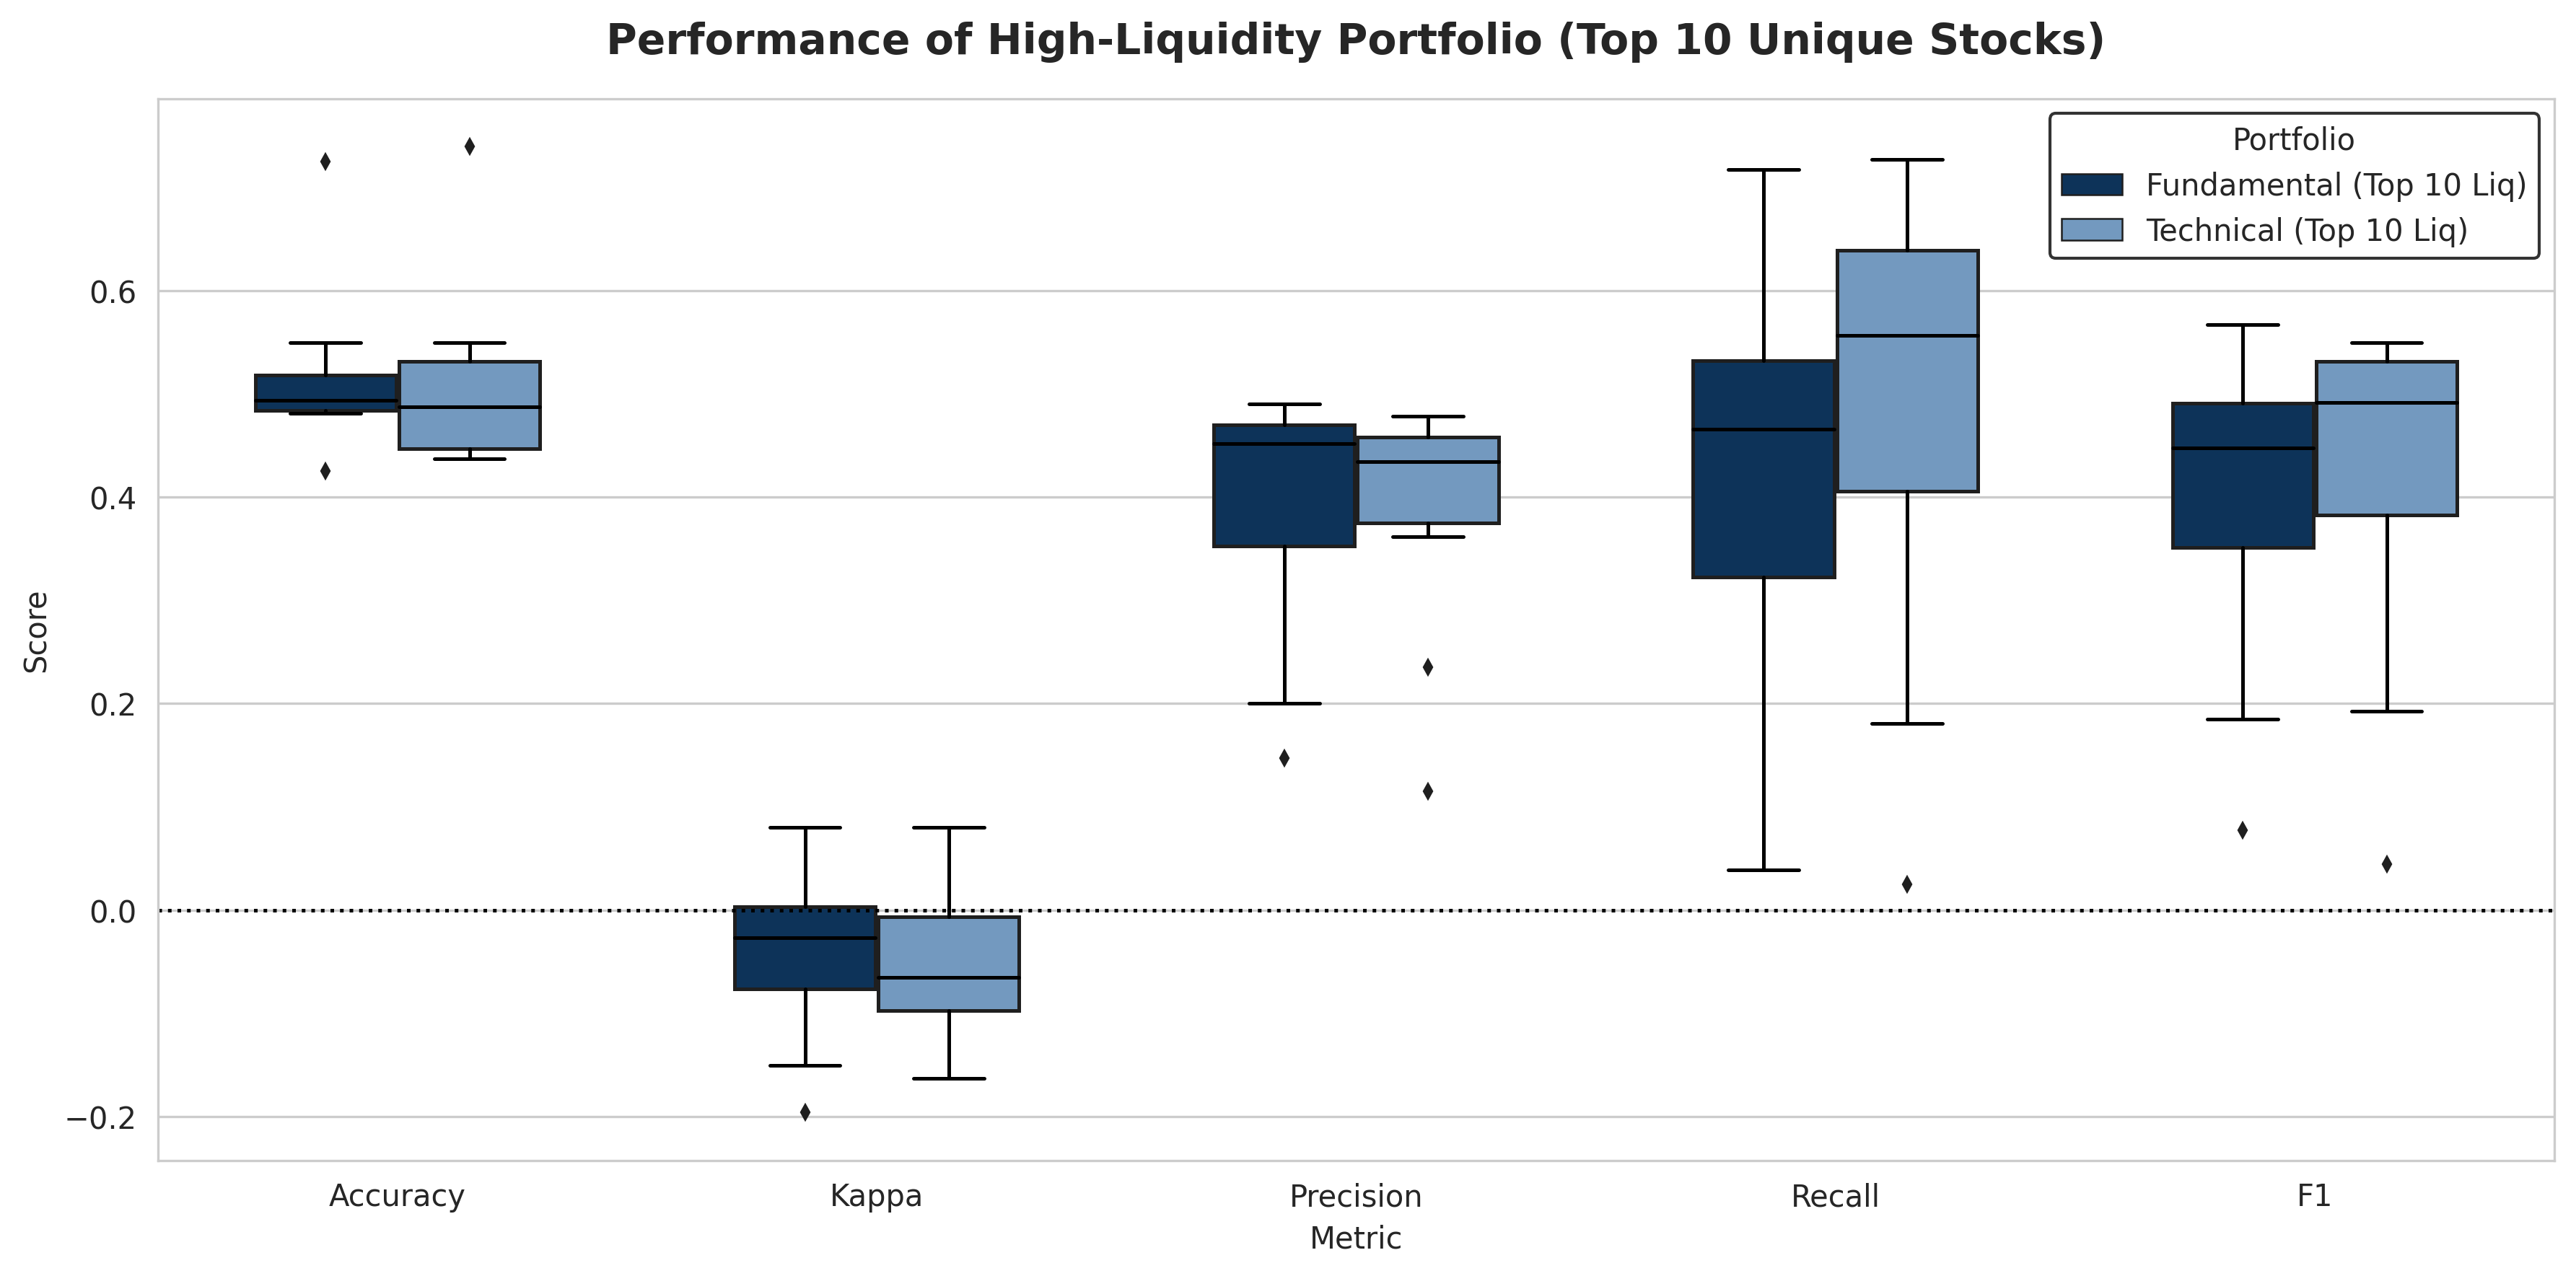

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# ==============================================================================
# 1. CONFIGURAÇÕES & LISTA DE VOLUME
# ==============================================================================
modelo = 'HT'
atraso_selecionado = 1
caminho_base = 'resultados'
nome_arquivo_saida = 'volume_portfolio_performance.pdf'
COLUNA_ATIVO = 'base' 

# Lista simulada de maiores volumes (ordem decrescente aproximada do IBOV)
# Se você tiver o dado real de volume, substitua isso por um sort_values('volume')
top_volume_tickers = ['VALE3', 'PETR4', 'ITUB4', 'BBDC4', 'BBAS3', 'PETR3', 'RENT3', 'ELET3', 'LREN3', 'GGBR4', 'EQTL3', 'AMER3', 'HYPE3', 'RADL3', 'BRFS3', 'CIEL3', 'EMBR3', 'TOTS3', 'CCRO3', 'CMIG4', 'CYRE3', 'MULT3', 'ELET6', 'USIM5', 'BBDC3', 'BEEF3', 'ENBR3', 'CPFE3', 'SLCE3', 'ALPA4', 'MDIA3', 'TRPL4', 'DXCO3', 'GFSA3', 'DIRR3', 'KEPL3', 'ODPV3', 'POMO4', 'MYPK3', 'POSI3', 'BRSR6', 'UNIP6', 'ITUB3', 'ABCB4', 'GRND3', 'MILS3', 'FESA4', 'SAPR4', 'CMIG3', 'LOGN3', 'USIM3', 'HBOR3', 'FHER3', 'GGBR3', 'CSUD3', 'PDGR3', 'RSID3', 'NEXP3']

mapa_nomes = {'fund': 'Fundamental (Top 10 Liq)', 'nao_fund': 'Technical (Top 10 Liq)'}
palette_vol = {'Fundamental (Top 10 Liq)': '#003366', 'Technical (Top 10 Liq)': '#6699CC'} # Azul "Blue Chip"

# ==============================================================================
# 2. CARREGAMENTO (COM MOCK PARA DEMONSTRAÇÃO)
# ==============================================================================
nome_arquivo = f'resultados_{modelo}_atraso_{atraso_selecionado}.csv'
caminho_completo = os.path.join(caminho_base, nome_arquivo)

if not os.path.exists(caminho_completo):
    print("AVISO: Usando dados simulados para demonstrar a lógica.")
    data = []
    # Cria dados simulados misturando Blue Chips e outros
    todos_tickers = top_volume_tickers + [f'SMALL{i}' for i in range(30)]
    for cat in ['fund', 'nao_fund']:
        for ticker in todos_tickers:
            # Simulação: Blue Chips (Fund) são mais estáveis (Kappa ~0.08), Small Caps piores
            is_blue = ticker in top_volume_tickers
            base_kappa = 0.08 if (cat == 'fund' and is_blue) else -0.02
            
            for h in range(9):
                acc = 0.52 + (base_kappa/2) + np.random.normal(0, 0.01)
                data.append({
                    'categoria': cat,
                    'base': ticker,
                    'Accuracy': acc,
                    'Kappa': (acc - 0.5) * 2,
                    'Precision': acc - 0.01,
                    'Recall': acc + 0.01
                })
    df = pd.read_csv(caminho_completo) if os.path.exists(caminho_completo) else pd.DataFrame(data)
else:
    df = pd.read_csv(caminho_completo)

# Limpeza básica
cols_numericas = ['Accuracy', 'Kappa', 'Precision', 'Recall', 'F1']
for col in cols_numericas:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.replace(',', '.')
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'F1' not in df.columns and 'Precision' in df.columns:
    df['F1'] = 2 * (df['Precision'] * df['Recall']) / (df['Precision'] + df['Recall'] + 1e-9)

# ==============================================================================
# 3. LÓGICA DE SELEÇÃO (TOP 10 VOLUME ÚNICO)
# ==============================================================================
selecionados = []
empresas_vistas = set()

print("Selecionando Top 10 por Liquidez (sem repetir empresa)...")

# Itera sobre a lista de volume (do maior para o menor)
for ticker in top_volume_tickers:
    # Pega os 4 primeiros caracteres como identificador da empresa (ex: PETR)
    empresa = ticker[:4]
    
    # Verifica se o ticker existe no nosso DataFrame
    if ticker in df[COLUNA_ATIVO].unique():
        if empresa not in empresas_vistas:
            selecionados.append(ticker)
            empresas_vistas.add(empresa)
            print(f"-> Adicionado: {ticker} (Empresa: {empresa})")
        else:
            print(f"-> Pulando: {ticker} (Empresa {empresa} já selecionada)")
    
    if len(selecionados) == 10:
        break

print(f"\nCarteira Final ({len(selecionados)} ativos): {selecionados}")

# Filtrar o DataFrame
df_liq = df[df[COLUNA_ATIVO].isin(selecionados)].copy()
df_liq['Domain_Vol'] = df_liq['categoria'].map(mapa_nomes)

# ==============================================================================
# 4. PLOTAGEM
# ==============================================================================
# Média por ativo
df_agrupado = df_liq.groupby(['Domain_Vol', COLUNA_ATIVO])[cols_numericas].mean().reset_index()

df_melted = df_agrupado.melt(
    id_vars=['Domain_Vol'], value_vars=cols_numericas,
    var_name='Metric', value_name='Score'
)

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6), dpi=300)

ax = sns.boxplot(
    data=df_melted, x='Metric', y='Score', hue='Domain_Vol',
    palette=palette_vol, linewidth=1.2, fliersize=3, width=0.6
)

for line in ax.lines: line.set_color('black')

plt.title('Performance of High-Liquidity Portfolio (Top 10 Unique Stocks)', 
          fontsize=14, fontweight='bold', pad=15)
plt.axhline(0, color='black', linestyle=':', linewidth=1.2)
plt.legend(title='Portfolio', loc='upper right', frameon=True, edgecolor='black')

plt.tight_layout()
plt.show() # Salva ou mostra

Lendo arquivo: resultados/resultados_HT_atraso_1.csv...
Calculando métricas a partir da Matriz de Confusão...


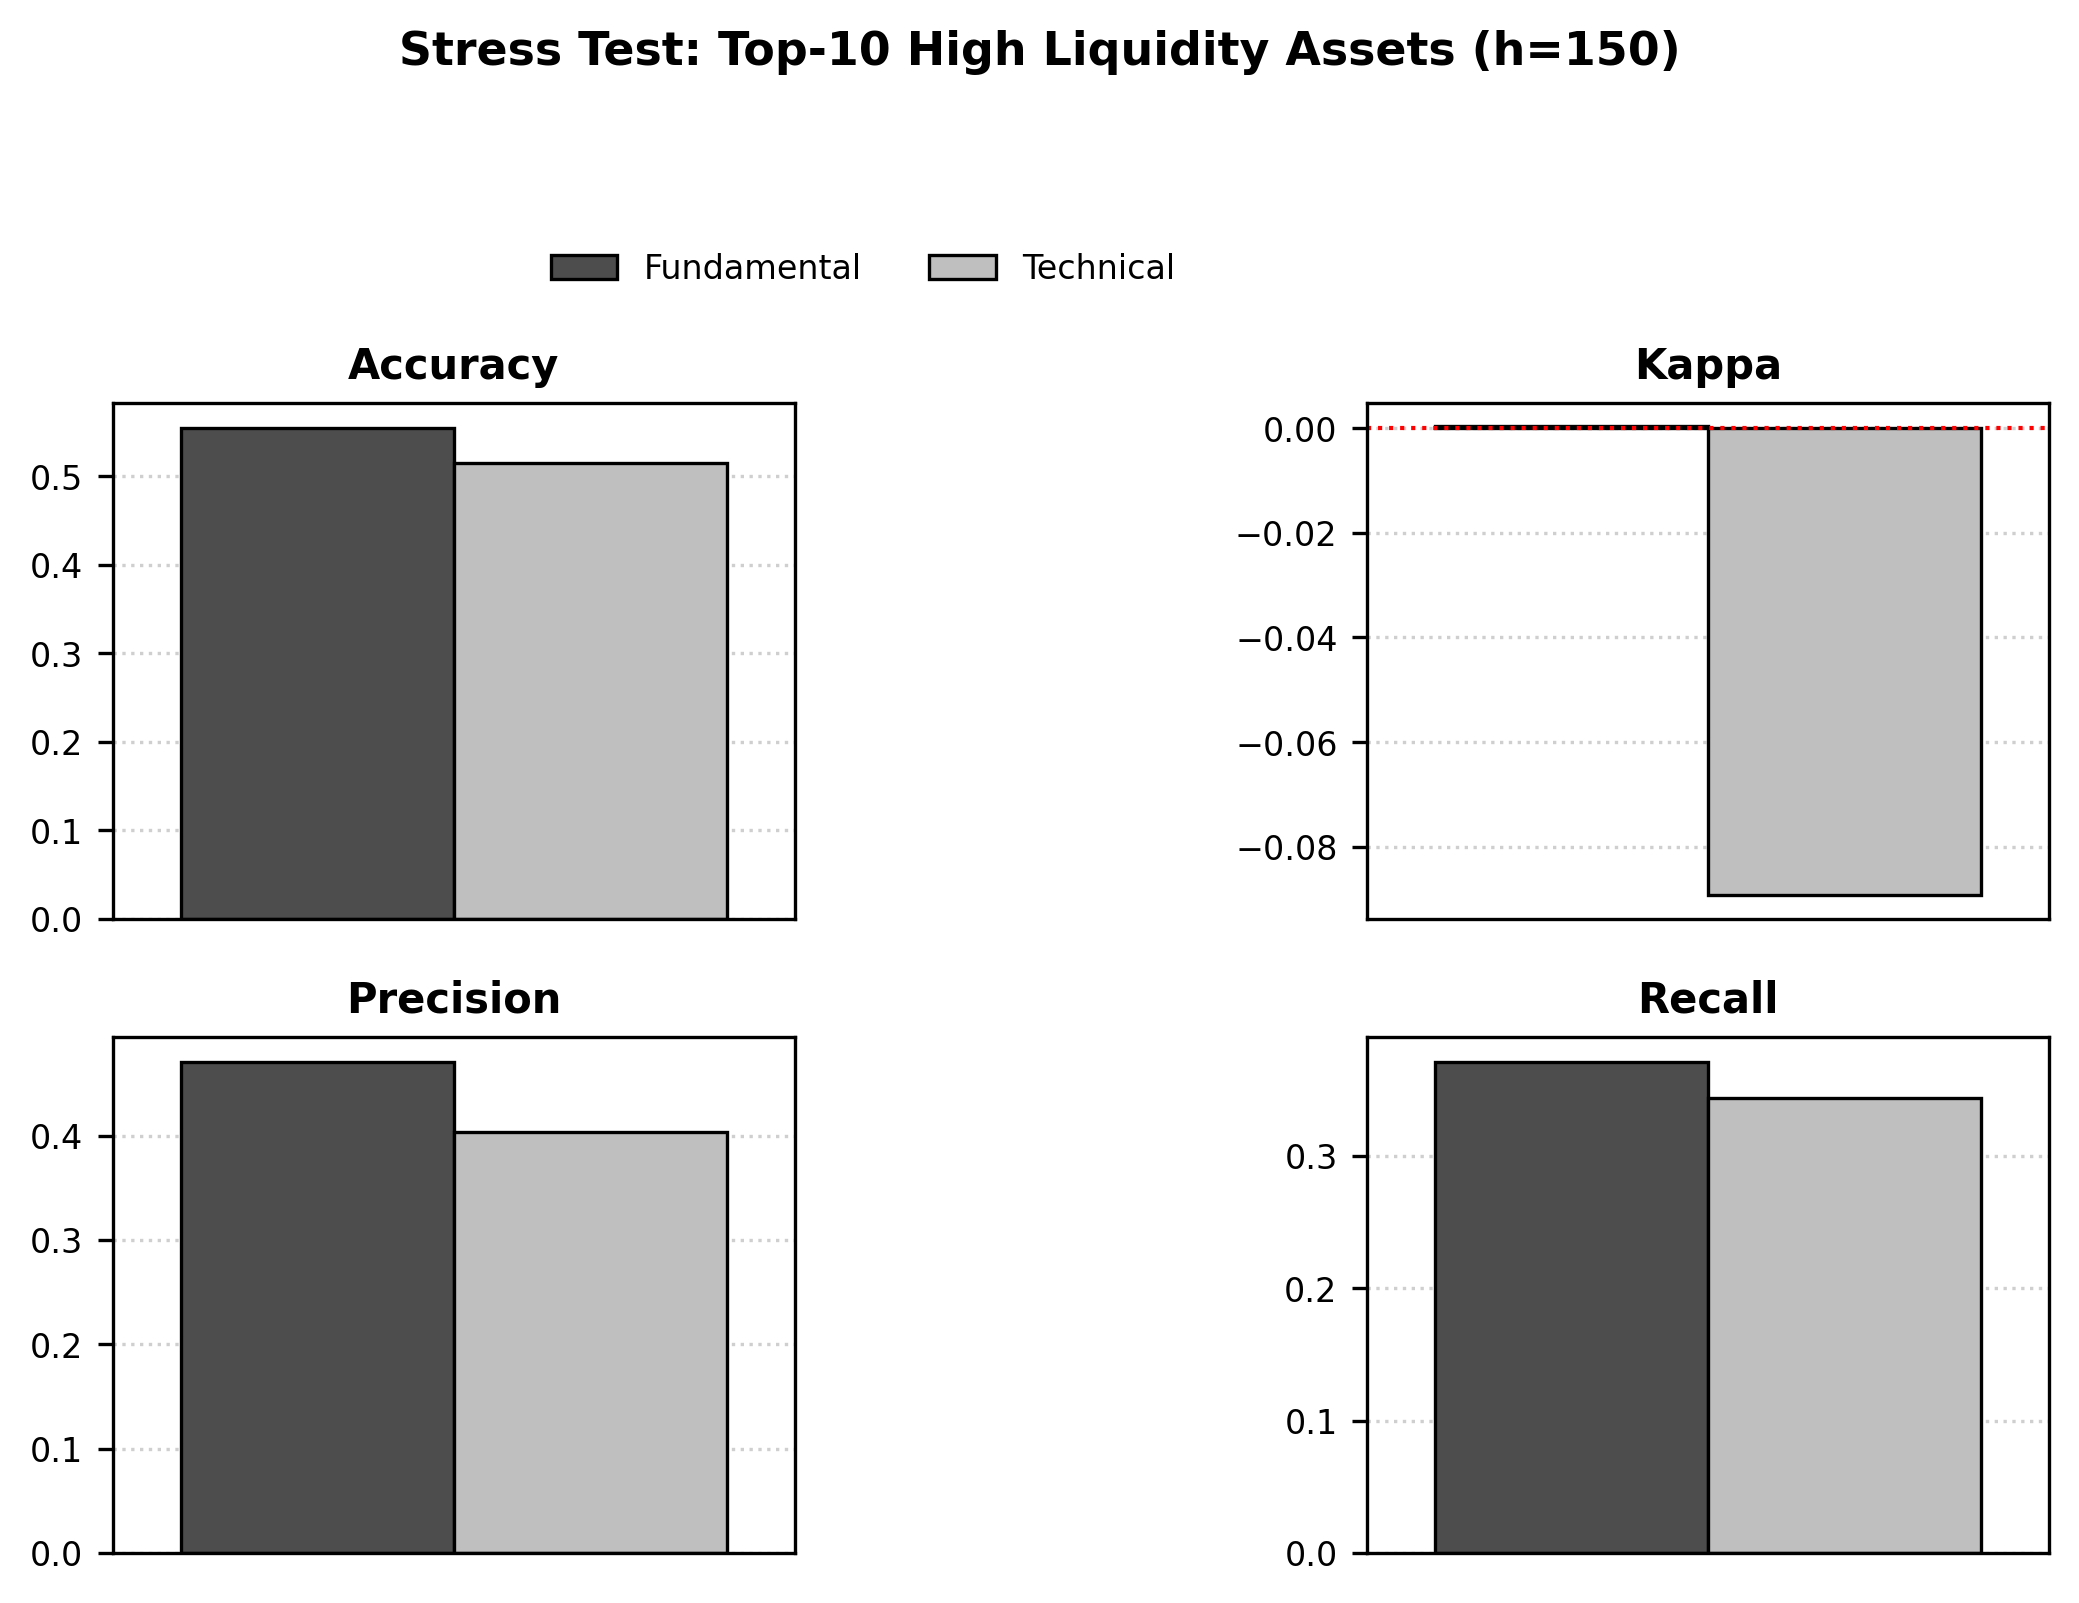

Gráfico gerado com dados reais: stress_test_real_h150.pdf

--- Resultados Médios (Macro-Average) dos Top 10 ---
        Domain  Accuracy     Kappa  Precision    Recall
0  Fundamental  0.554917  0.000319   0.470747  0.370915
1    Technical  0.515140 -0.089309   0.403252  0.343780


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# ==============================================================================
# 1. CONFIGURAÇÃO (ARQUIVO E ATIVOS)
# ==============================================================================
# Nome do arquivo de resultados (ajuste se necessário)
caminho_arquivo = 'resultados/resultados_HT_atraso_1.csv' 

# Horizonte do "Sweet Spot"
horizonte_alvo = 150

# Lista dos Top 10 Ativos de Alta Liquidez (Verifique os nomes no seu CSV)
# Se no seu CSV for "PETR4.SA", adicione o .SA aqui também.
top_10_assets = [
    'VALE3', 'PETR4', 'ITUB4', 'RENT3', 'ELET3', 'LREN3', 'GGBR4', 'EQTL3', 'AMER3', 'HYPE3'
]

# Mapeamento de nomes (De -> Para)
mapa_nomes = {'fund': 'Fundamental', 'nao_fund': 'Technical'}
palette_map = {'Fundamental': '#4D4D4D', 'Technical': '#BFBFBF'}

# Configuração IEEE
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 300
})

# ==============================================================================
# 2. CARREGAMENTO E FILTRAGEM DOS DADOS REAIS
# ==============================================================================
if not os.path.exists(caminho_arquivo):
    raise FileNotFoundError(f"Arquivo não encontrado: {caminho_arquivo}")

print(f"Lendo arquivo: {caminho_arquivo}...")
df = pd.read_csv(caminho_arquivo)

# Normalização de nomes de colunas (para garantir compatibilidade)
# Se sua coluna for 'fh', renomeia para 'horizon' para padronizar
if 'fh' in df.columns:
    df.rename(columns={'fh': 'horizon'}, inplace=True)

# 1. Filtrar pelo Horizonte H=150
df_filtered = df[df['horizon'] == horizonte_alvo].copy()

# 2. Filtrar apenas os Top 10 Ativos
# Verifica se os ativos estão no CSV
ativos_no_csv = df_filtered['base'].unique()
ativos_encontrados = [a for a in top_10_assets if a in ativos_no_csv]

if len(ativos_encontrados) < len(top_10_assets):
    print("AVISO: Alguns ativos da lista não foram encontrados no CSV.")
    print(f"Procurados: {top_10_assets}")
    print(f"Encontrados: {ativos_encontrados}")

df_target = df_filtered[df_filtered['base'].isin(ativos_encontrados)].copy()

# ==============================================================================
# 3. CÁLCULO DAS MÉTRICAS (SE JÁ NÃO EXISTIREM)
# ==============================================================================
# Se o CSV tiver apenas TP, TN, FP, FN, calculamos as métricas aqui.
# Se já tiver 'kappa', 'accuracy', etc., essa parte sobrescreve ou ignora.

# Garante que as colunas são numéricas
cols_confusao = ['TP', 'TN', 'FP', 'FN']
for col in cols_confusao:
    if col in df_target.columns:
        df_target[col] = pd.to_numeric(df_target[col])

# Função auxiliar para Kappa
def calculate_kappa(row):
    total = row['TP'] + row['TN'] + row['FP'] + row['FN']
    if total == 0: return 0
    po = (row['TP'] + row['TN']) / total
    pe_pos = ((row['TP'] + row['FP']) * (row['TP'] + row['FN'])) / (total**2)
    pe_neg = ((row['TN'] + row['FN']) * (row['TN'] + row['FP'])) / (total**2)
    pe = pe_pos + pe_neg
    if pe == 1: return 0
    return (po - pe) / (1 - pe)

# Calcula/Recalcula métricas para garantir precisão
print("Calculando métricas a partir da Matriz de Confusão...")
df_target['Total'] = df_target['TP'] + df_target['TN'] + df_target['FP'] + df_target['FN']
df_target['Accuracy'] = (df_target['TP'] + df_target['TN']) / df_target['Total']
df_target['Precision'] = df_target['TP'] / (df_target['TP'] + df_target['FP'])
df_target['Recall'] = df_target['TP'] / (df_target['TP'] + df_target['FN'])
df_target['Kappa'] = df_target.apply(calculate_kappa, axis=1)

# Mapeia nomes das categorias
df_target['Domain'] = df_target['categoria'].map(mapa_nomes)

# ==============================================================================
# 4. AGREGAÇÃO MACRO (MÉDIA DO PORTFÓLIO)
# ==============================================================================
# Agrupa por Domínio e tira a média das métricas dos 10 ativos
df_macro = df_target.groupby('Domain')[['Accuracy', 'Kappa', 'Precision', 'Recall']].mean().reset_index()

# Prepara para o Seaborn (formato longo)
df_melted = df_macro.melt(id_vars='Domain', var_name='Metric', value_name='Score')

# ==============================================================================
# 5. PLOTAGEM
# ==============================================================================
metrics_order = ['Accuracy', 'Kappa', 'Precision', 'Recall']

fig, axes = plt.subplots(2, 2, figsize=(7, 5.5)) 
axes = axes.flatten()

for i, metric in enumerate(metrics_order):
    ax = axes[i]
    
    subset = df_melted[df_melted['Metric'] == metric]
    
    # Gráfico de barras
    sns.barplot(
        data=subset,
        x='Metric',
        y='Score',
        hue='Domain',
        palette=palette_map,
        edgecolor='black',
        linewidth=0.8,
        ax=ax
        # width removido para segurança
    )
    
    # Estilização
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([]) # Limpa eixo X
    
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    
    # Linha zero para Kappa
    if metric == 'Kappa':
        ax.axhline(0, color='red', linestyle=':', linewidth=1)

    # Legenda (apenas no primeiro)
    if i == 0:
        ax.legend(title='', frameon=False, loc='upper center', 
                  bbox_to_anchor=(1.1, 1.35), ncol=2)
    else:
        if ax.get_legend():
            ax.get_legend().remove()

plt.suptitle(f'Stress Test: Top-10 High Liquidity Assets (h={horizonte_alvo})', 
             y=0.96, fontsize=11, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.92])
nome_saida = f'stress_test_real_h{horizonte_alvo}.pdf'
plt.savefig(nome_saida, bbox_inches='tight')
plt.show()

print(f"Gráfico gerado com dados reais: {nome_saida}")
print("\n--- Resultados Médios (Macro-Average) dos Top 10 ---")
print(df_macro)

Lendo arquivo: resultados/resultados_HT_atraso_1.csv...


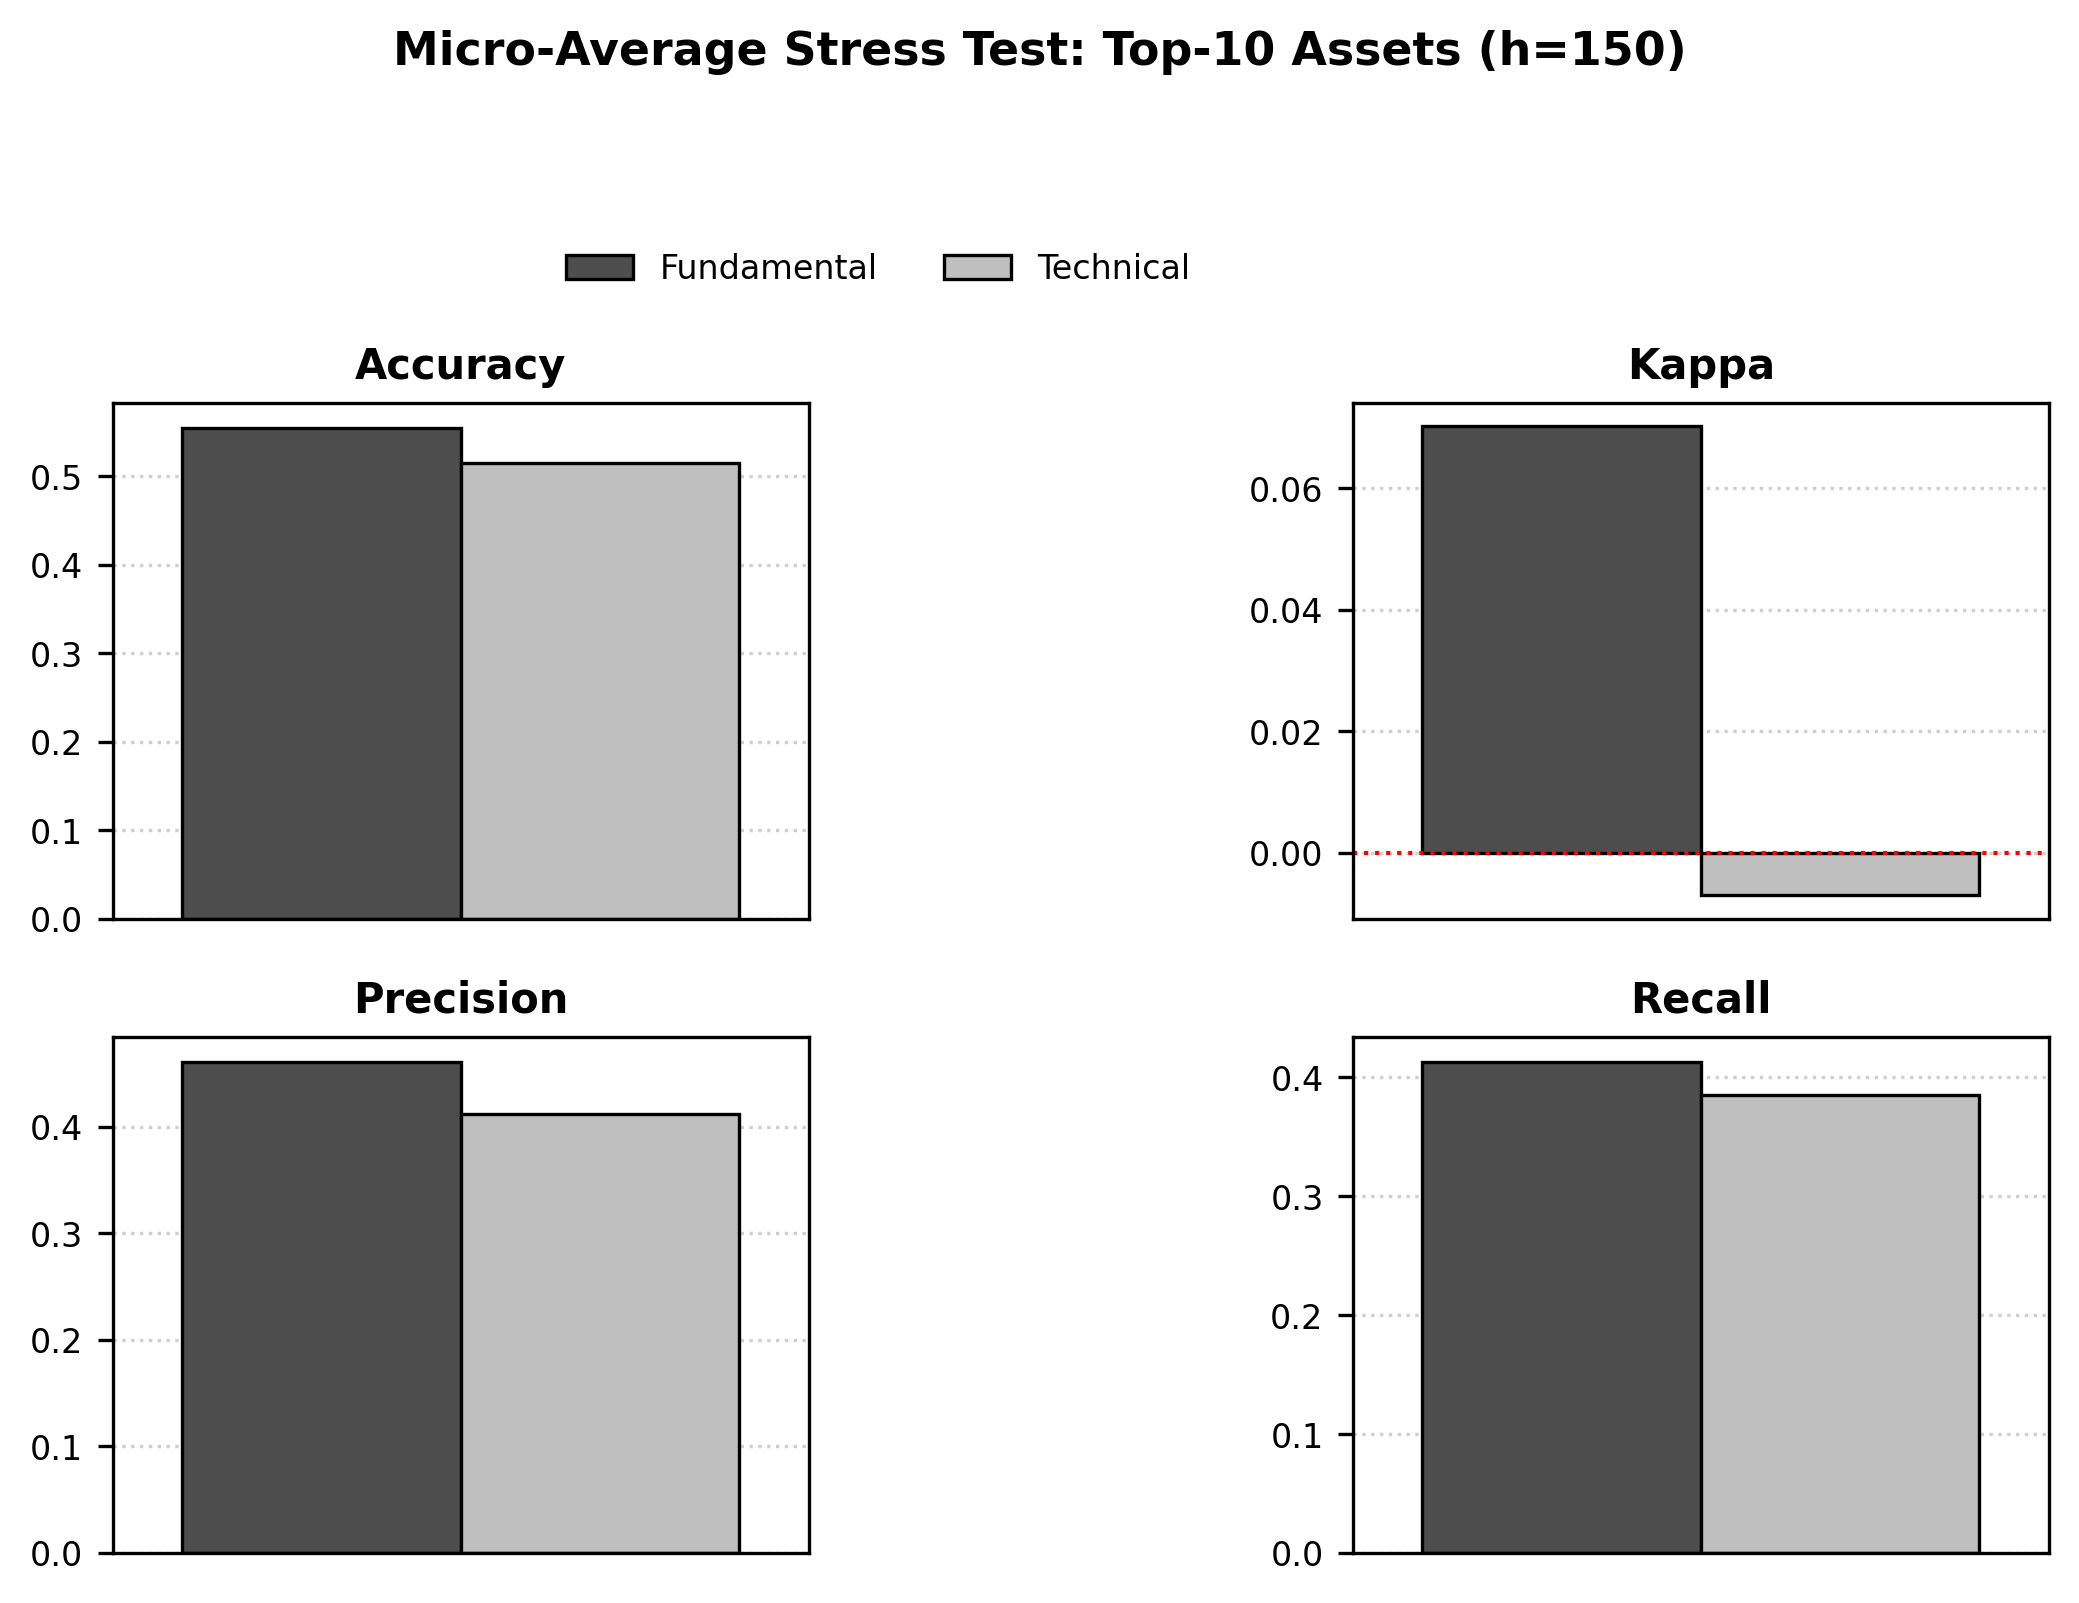

Gráfico Micro-Average gerado: stress_test_micro_h150.pdf

--- Resultados Globais (Micro-Average) ---
        Domain  Accuracy     Kappa  Precision    Recall
0  Fundamental  0.554970  0.070183   0.461150  0.412994
1    Technical  0.515173 -0.007049   0.411719  0.385304


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# ==============================================================================
# 1. CONFIGURAÇÃO (ARQUIVO E ATIVOS)
# ==============================================================================
caminho_arquivo = 'resultados/resultados_HT_atraso_1.csv' 
horizonte_alvo = 150

top_10_assets = [
    'VALE3', 'PETR4', 'ITUB4', 'RENT3', 'ELET3', 'LREN3', 'GGBR4', 'EQTL3', 'AMER3', 'HYPE3'
]

mapa_nomes = {'fund': 'Fundamental', 'nao_fund': 'Technical'}
palette_map = {'Fundamental': '#4D4D4D', 'Technical': '#BFBFBF'}

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 300
})

# ==============================================================================
# 2. CARREGAMENTO E FILTRAGEM
# ==============================================================================
if not os.path.exists(caminho_arquivo):
    raise FileNotFoundError(f"Arquivo não encontrado: {caminho_arquivo}")

print(f"Lendo arquivo: {caminho_arquivo}...")
df = pd.read_csv(caminho_arquivo)

if 'fh' in df.columns:
    df.rename(columns={'fh': 'horizon'}, inplace=True)

# Filtra Horizonte e Ativos
df_filtered = df[df['horizon'] == horizonte_alvo].copy()
ativos_no_csv = df_filtered['base'].unique()
ativos_encontrados = [a for a in top_10_assets if a in ativos_no_csv]

if len(ativos_encontrados) < len(top_10_assets):
    print(f"AVISO: Apenas {len(ativos_encontrados)} ativos encontrados dos {len(top_10_assets)} procurados.")

df_target = df_filtered[df_filtered['base'].isin(ativos_encontrados)].copy()
df_target['Domain'] = df_target['categoria'].map(mapa_nomes)

# ==============================================================================
# 3. CÁLCULO MICRO-AVERAGE (A MUDANÇA PRINCIPAL)
# ==============================================================================
# Agrupa por Domínio e SOMA as contagens brutas (TP, TN, FP, FN)
df_micro = df_target.groupby('Domain')[['TP', 'TN', 'FP', 'FN']].sum().reset_index()

# Calcula as métricas com base nos totais somados
total = df_micro['TP'] + df_micro['TN'] + df_micro['FP'] + df_micro['FN']

# Accuracy
df_micro['Accuracy'] = (df_micro['TP'] + df_micro['TN']) / total

# Precision e Recall
df_micro['Precision'] = df_micro['TP'] / (df_micro['TP'] + df_micro['FP'])
df_micro['Recall'] = df_micro['TP'] / (df_micro['TP'] + df_micro['FN'])

# Kappa
po = df_micro['Accuracy']
pe_pos = ((df_micro['TP'] + df_micro['FP']) * (df_micro['TP'] + df_micro['FN'])) / (total**2)
pe_neg = ((df_micro['TN'] + df_micro['FN']) * (df_micro['TN'] + df_micro['FP'])) / (total**2)
pe = pe_pos + pe_neg
df_micro['Kappa'] = (po - pe) / (1 - pe)

# Prepara para plotagem
df_melted = df_micro.melt(id_vars='Domain', value_vars=['Accuracy', 'Kappa', 'Precision', 'Recall'], 
                          var_name='Metric', value_name='Score')

# ==============================================================================
# 4. PLOTAGEM
# ==============================================================================
metrics_order = ['Accuracy', 'Kappa', 'Precision', 'Recall']

fig, axes = plt.subplots(2, 2, figsize=(7, 5.5)) 
axes = axes.flatten()

for i, metric in enumerate(metrics_order):
    ax = axes[i]
    
    subset = df_melted[df_melted['Metric'] == metric]
    
    sns.barplot(
        data=subset,
        x='Metric',
        y='Score',
        hue='Domain',
        palette=palette_map,
        edgecolor='black',
        linewidth=0.8,
        ax=ax
    )
    
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([]) 
    
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    
    if metric == 'Kappa':
        ax.axhline(0, color='red', linestyle=':', linewidth=1)

    if i == 0:
        ax.legend(title='', frameon=False, loc='upper center', 
                  bbox_to_anchor=(1.1, 1.35), ncol=2)
    else:
        if ax.get_legend():
            ax.get_legend().remove()

plt.suptitle(f'Micro-Average Stress Test: Top-10 Assets (h={horizonte_alvo})', 
             y=0.96, fontsize=11, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.92])
nome_saida = f'stress_test_micro_h{horizonte_alvo}.pdf'
plt.savefig(nome_saida, bbox_inches='tight')
plt.show()

print(f"Gráfico Micro-Average gerado: {nome_saida}")
print("\n--- Resultados Globais (Micro-Average) ---")
print(df_micro[['Domain', 'Accuracy', 'Kappa', 'Precision', 'Recall']])